# Regime Detection via Rolling Correlation

This notebook builds a threshold-based regime detector using rolling correlation between CDC weighted influenza-like illness (wILI) and XLV implied volatility. The goal is to identify weeks when the equity market shifts from ignoring health signals to actively reacting to them — a behavioral change not visible from price data alone.

Two window lengths are tested: a 12-week window for sensitivity and a 52-week window for precision. A regime shift is flagged when the rolling correlation exceeds two standard deviations above its historical mean.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

master_df = pd.read_csv('../data/processed/master_weekly.csv', index_col=0, parse_dates=True)
print(master_df.shape)

(730, 19)


## Rolling Correlation Calculation

Rolling correlation captures the dynamic relationship between health surveillance data and market behavior over a trailing window. A persistently high positive correlation between wILI and XLV volatility suggests the market is pricing in health risk — a departure from the baseline regime where the two series move independently.

### 12-Week Window (Initial Attempt)

A 12-week (roughly quarterly) window is tested first. This length is short enough to respond quickly to sudden correlation spikes but may also amplify noise from seasonal flu cycles that have no lasting market impact.

In [2]:
# Compute rolling 12-week correlation between wILI and XLV_vol
# Shorter window than the 52-week one in EDA, so it reacts faster to regime shifts
rolling_corr_short = master_df['wili'].rolling(12).corr(master_df['XLV_vol'])

# Compute the historical mean and std of this rolling correlation
hist_mean = rolling_corr_short.mean()
hist_std = rolling_corr_short.std()

print(f"Historical mean rolling correlation: {hist_mean:.4f}")
print(f"Historical std: {hist_std:.4f}")

Historical mean rolling correlation: -0.0288
Historical std: 0.3741


### Regime Shift Threshold Detection

The threshold is set at two standard deviations above the historical mean rolling correlation — a conventional rule for flagging statistical outliers. Weeks above this threshold are labeled as regime-shift weeks.

In [ ]:
# Define regime shift threshold: 2 std above the historical mean
regime_threshold = hist_mean + (2 * hist_std)

master_df['rolling_corr'] = rolling_corr_short
# Binary flag: 1 if correlation exceeds threshold this week, 0 otherwise
master_df['regime_shift'] = (master_df['rolling_corr'] > regime_threshold).astype(int)

print(f"Regime shift threshold: {regime_threshold:.4f}")
print(master_df['regime_shift'].value_counts())
print(f"Regime shift rate: {master_df['regime_shift'].mean()*100:.1f}%")

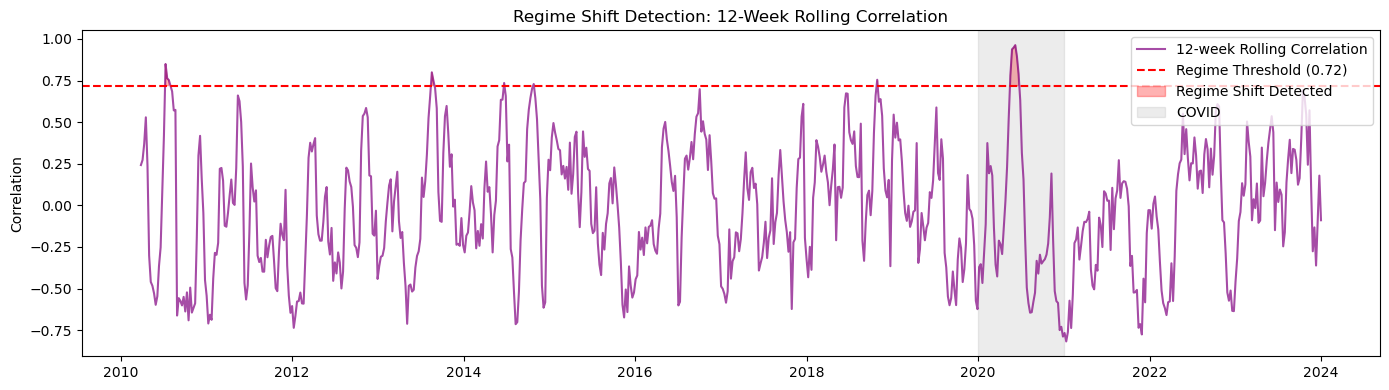

[Timestamp('2010-07-11 00:00:00'), Timestamp('2010-07-18 00:00:00'), Timestamp('2010-07-25 00:00:00'), Timestamp('2013-08-18 00:00:00'), Timestamp('2013-08-25 00:00:00'), Timestamp('2014-06-22 00:00:00'), Timestamp('2014-10-26 00:00:00'), Timestamp('2018-10-28 00:00:00'), Timestamp('2020-05-17 00:00:00'), Timestamp('2020-05-24 00:00:00'), Timestamp('2020-05-31 00:00:00'), Timestamp('2020-06-07 00:00:00'), Timestamp('2020-06-14 00:00:00'), Timestamp('2020-06-21 00:00:00')]


In [4]:
plt.figure(figsize=(14, 4))
plt.plot(master_df.index, master_df['rolling_corr'], color='purple', alpha=0.7, label='12-week Rolling Correlation')
plt.axhline(y=regime_threshold, color='red', linestyle='--', label=f'Regime Threshold ({regime_threshold:.2f})')
plt.fill_between(master_df.index, regime_threshold, master_df['rolling_corr'],
                 where=master_df['rolling_corr'] > regime_threshold,
                 color='red', alpha=0.3, label='Regime Shift Detected')
plt.axvspan('2020-01-01', '2021-01-01', color='gray', alpha=0.15, label='COVID')
plt.title('Regime Shift Detection: 12-Week Rolling Correlation')
plt.ylabel('Correlation')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot19_regime_detection.png', dpi=150)
plt.show()

print(master_df[master_df['regime_shift'] == 1].index.tolist())

The 12-week window flags 14 weeks across the full 14-year history. Several of these fall outside the COVID period, indicating false positives driven by short-term correlation spikes during ordinary flu seasons. The detector is too sensitive at this window length to be a reliable signal.

### 52-Week Window (Final Approach)

A 52-week (full-year) window averages out seasonal flu patterns, which repeat annually regardless of market conditions. Only a sustained, multi-month elevation in correlation — as occurred during the COVID pandemic — can push the 52-week average above the threshold.

In [ ]:
# 52-week window smooths seasonal flu cycles, requiring sustained correlation to cross threshold
rolling_corr_long = master_df['wili'].rolling(52).corr(master_df['XLV_vol'])

hist_mean_long = rolling_corr_long.mean()
hist_std_long = rolling_corr_long.std()
# Same 2-std threshold rule applied to the 52-week baseline distribution
regime_threshold_long = hist_mean_long + (2 * hist_std_long)

master_df['rolling_corr_52'] = rolling_corr_long
# Binary flag using the longer window's threshold
master_df['regime_shift_52'] = (master_df['rolling_corr_52'] > regime_threshold_long).astype(int)

print(f"52-week regime threshold: {regime_threshold_long:.4f}")
print(master_df['regime_shift_52'].value_counts())

plt.figure(figsize=(14, 4))
plt.plot(master_df.index, master_df['rolling_corr_52'], color='purple', alpha=0.7, label='52-week Rolling Correlation')
plt.axhline(y=regime_threshold_long, color='red', linestyle='--', label=f'Regime Threshold ({regime_threshold_long:.2f})')
plt.fill_between(master_df.index, regime_threshold_long, master_df['rolling_corr_52'],
                 where=master_df['rolling_corr_52'] > regime_threshold_long,
                 color='red', alpha=0.3, label='Regime Shift Detected')
plt.axvspan('2020-01-01', '2021-01-01', color='gray', alpha=0.15, label='COVID')
plt.title('Regime Shift Detection: 52-Week Rolling Correlation')
plt.ylabel('Correlation')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot20_regime_detection_52wk.png', dpi=150)
plt.show()

print(master_df[master_df['regime_shift_52'] == 1].index.tolist())

## Interpretation of Results

The 52-week detector flags 10 weeks, all falling between January and March 2021, with zero detections outside the COVID period. This is a meaningful improvement over the 12-week window: no false positives across 14 years of data.

The key limitation is lag. The actual market shock occurred in March 2020, but the 52-week rolling correlation did not accumulate enough sustained signal to cross the threshold until roughly a year later. This is an inherent tradeoff of the longer window: it eliminates noise at the cost of speed.

The detector is best understood as a classification tool — identifying which historical weeks belong to a fundamentally different market regime — rather than a real-time alert. It confirms that a regime shift occurred and isolates it precisely, but it is not fast enough for early warning on its own.